<a href="https://colab.research.google.com/github/engmodu/AIFEL_quest_eng/blob/main/Deployment/deploy_08/deploy_08.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐶 [Day 8 프로젝트 리포트] AI 반려동물 속마음 번역기 서비스
> **과목**: 모델 배포 개론 자율 프로젝트 (Day 8)  
> **프로젝트명**: 비전 앙상블 기법(ViT + BLIP) 기반 반려동물 속마음 번역 및 서빙 대시보드  
> **개발자**: 박대건

본 리포트는 Day 1~7에서 학습한 모델 패키징, FastAPI 백엔드 구축, 비동기 연산 오프로딩, API Key 보안 인증 및 Streamlit 프론트엔드 시각화를 통합하여 구현한 **AI 반려동물 속마음 번역기**의 최종 제출 결과서입니다.

---

## 1. 프로젝트 개요 & 태스크 정의 (Project Overview)

* **선택 도메인**: 펫 테크 (Pet-Tech) & 정서적 교감 AI 서비스
* **선택 태스크**: 비전-언어 하이브리드 멀티모달 태스크 (Image Classification & Image Captioning)
* **목표**:
  반려동물의 사진을 업로드하거나 실시간 촬영했을 때, 동물의 품종과 행동 문맥을 AI가 파악하여 위트 있는 **한글 속마음 번역 카드**와 **집사용 돌봄 가이드 처방전**을 제공함으로써 반려가구의 정서적 만족과 올바른 케어를 돕습니다.

---

## 2. 사용 모델 및 선택 이유 (Model Specifications)

로컬 CPU 또는 Google Colab의 제한된 자원 환경에서도 신속히 돌릴 수 있도록 **500MB 이하의 경량 모델** 중 허깅페이스 `pipeline`과 즉시 호환되는 아래 2가지 모델을 선정해 **앙상블(Ensemble)** 아키텍처를 구성했습니다.

| 모델 구분 | 모델명 (Hugging Face ID) | 크기 | 역할 및 선정 이유 |
|---|---|---|---|
| **Model A (분류기)** | `google/vit-base-patch16-224` | 약 340MB | **품종 판별**: ImageNet-1k 데이터로 파인튜닝되어 골든 리트리버, 웰시코기, 태비 고양이 등 약 120종의 동물 품종을 높은 정확도(Top-1: 84.53%)로 분류해 줍니다. |
| **Model B (캡셔닝)** | `Salesforce/blip-image-captioning-base` | 약 370MB | **행동 분석**: 사진 속 대상의 동적인 행동을 인식해 주어, 동사, 목적어가 갖춰진 영어 캡션(예: `sleeping on the bed`)을 자동 서술해 줍니다. (COCO CIDEr Score: 133.3) |

---

## 3. 데모 실행 화면 (Demo Screenshots)

### 📸 Streamlit 프론트엔드 분석 성공 화면
사용자가 사진을 업로드(또는 실시간 카메라 촬영)하고 번역하기 버튼을 누르면, 백엔드로부터 전달받은 품종명, 영어 행동 캡션, 한글 속마음 말풍선, 돌봄 처방전 가이드 카드가 화면에 시각화되며 `st.balloons()` 축하 효과가 작동합니다.

![반려동물 번역기 화면]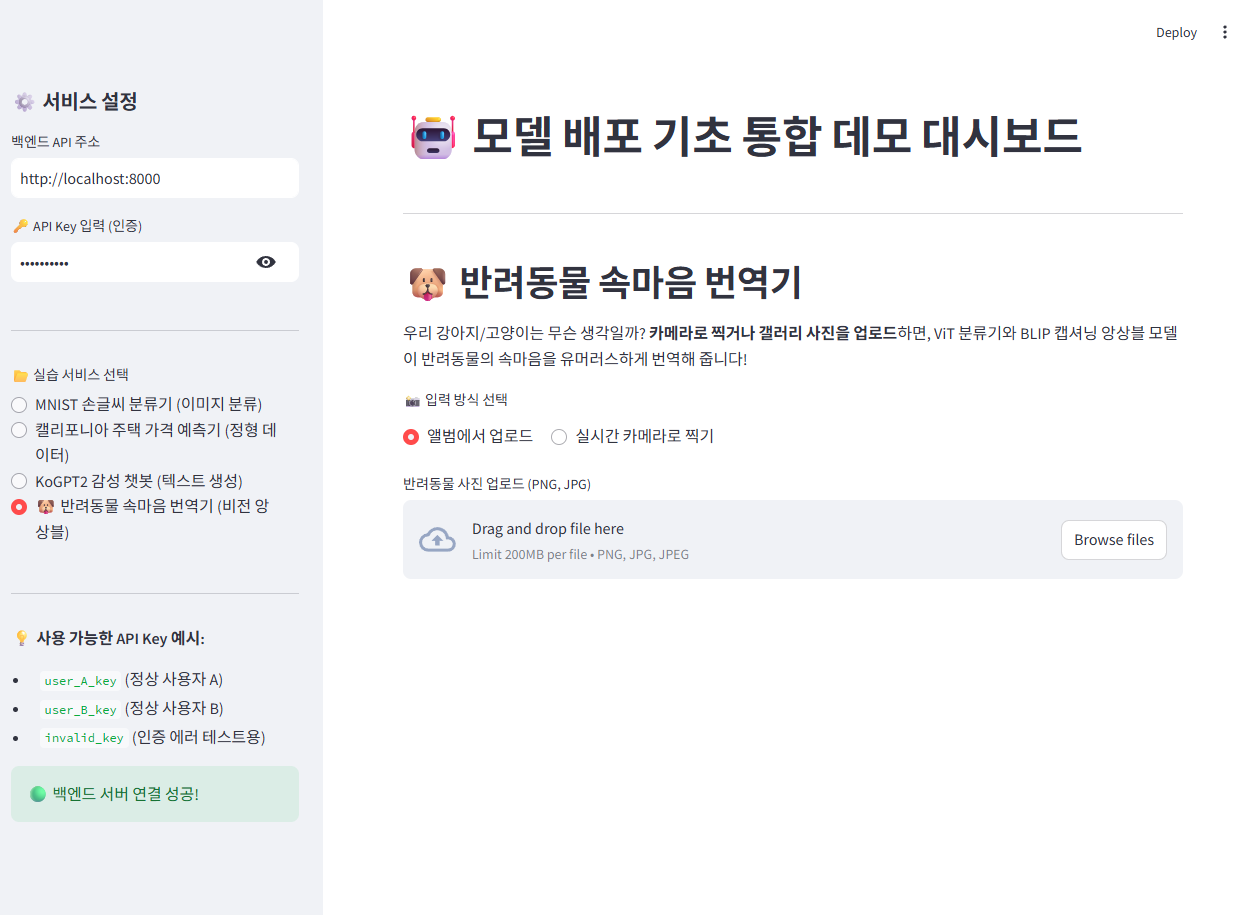

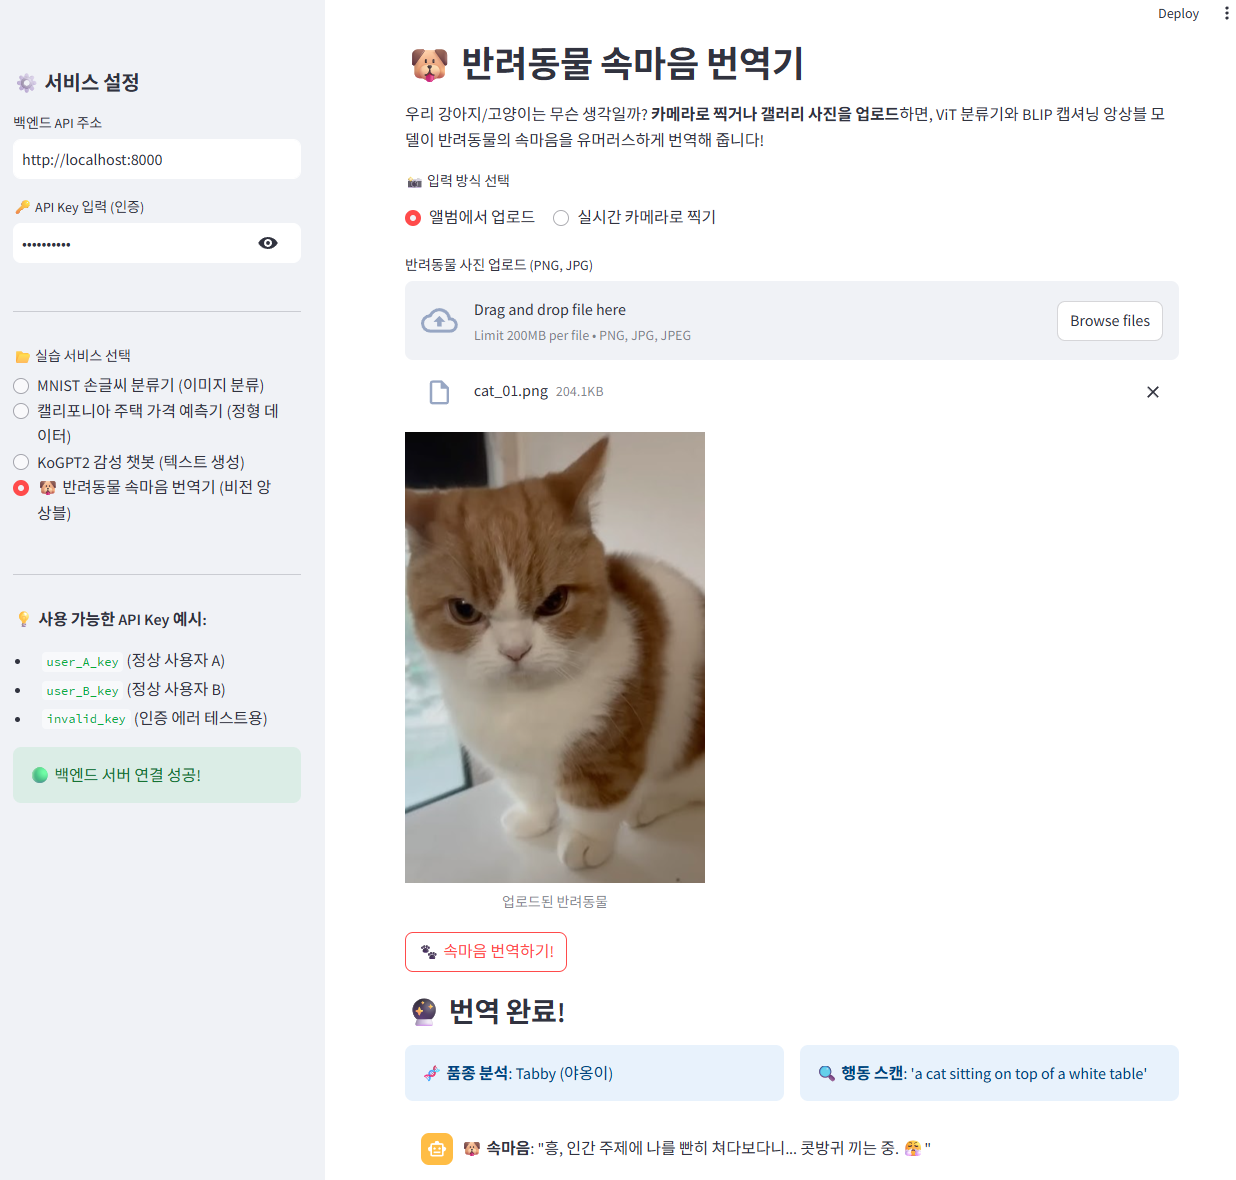


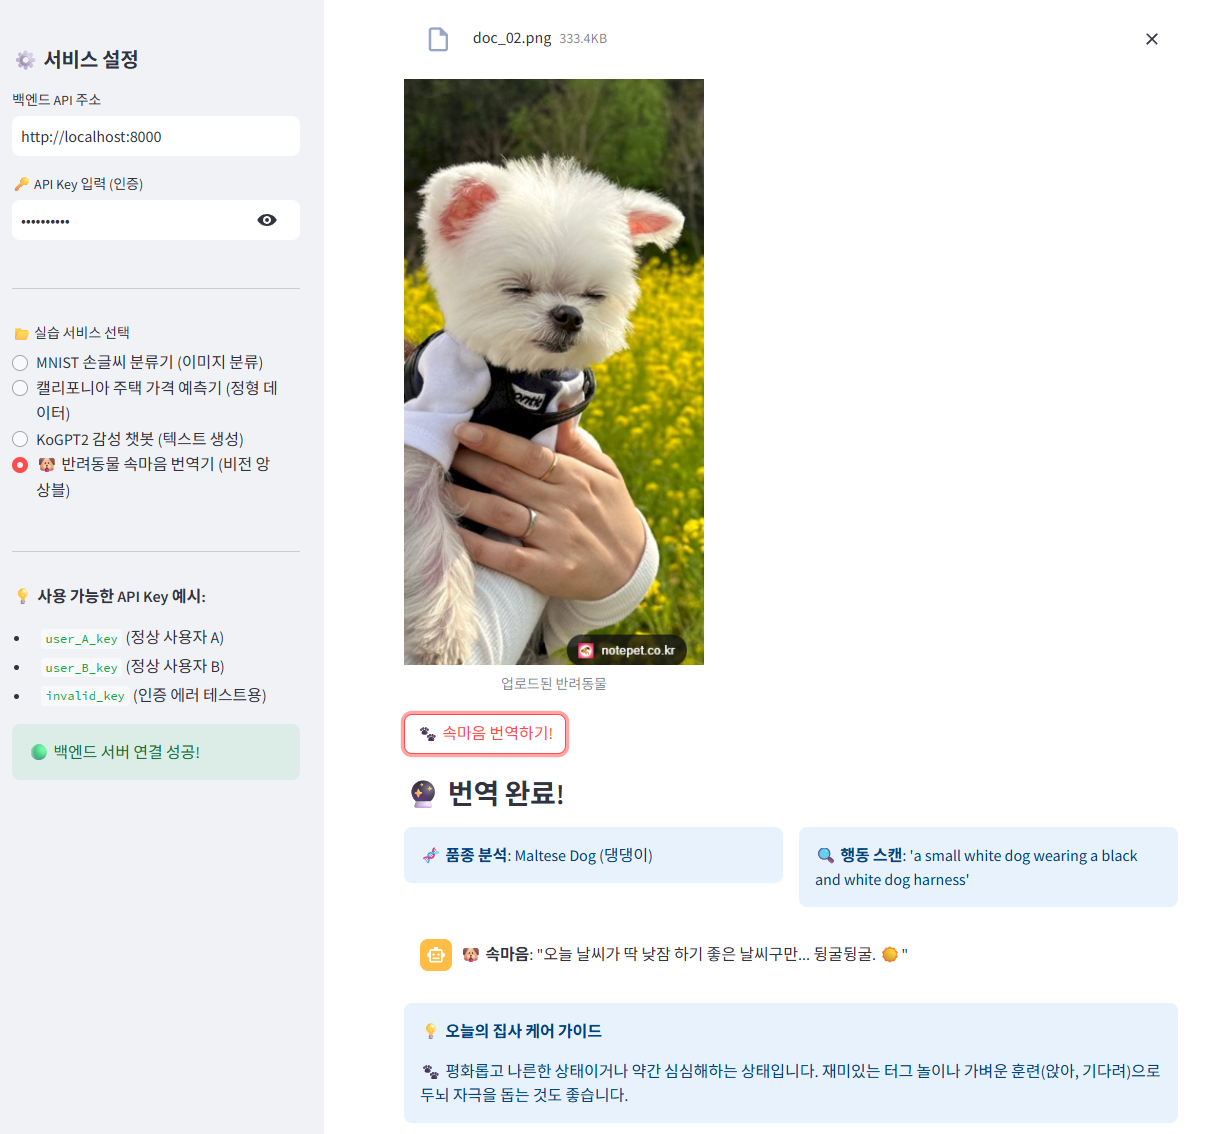

---

## 🧬 4. 시스템 아키텍처 및 트래픽 시퀀스

본 서비스는 FastAPI 주방(백엔드)과 Streamlit 테이블(프론트엔드)이 철저하게 분리되어 상호작용하도록 설계되었습니다.

### 🛠️ 프론트엔드와 백엔드의 레스토랑 협업 구조
* **Streamlit (프론트엔드)**: 손님 테이블. 이미지를 포장(Multipart/Form-data)하고 헤더에 보안 요원 패스용 API Key(`X-API-Key`)를 스탬프로 찍어 주문을 넣습니다.
* **FastAPI (백엔드)**: 비밀 주방. 지배인(FastAPI)이 보안 키 검사 및 5MB 크기를 검수한 뒤, 보조 요리사 스레드 풀에게 인공지능 요리를 위임합니다.

![레스토랑 비유 일러스트](submissions/assets/restaurant_illustration.png)

---

### ⏱️ 실시간 트래픽 처리 순서도 (Sequence Diagram)
데이터가 프론트엔드 브라우저에서 출발하여 AI 모델 앙상블 판독을 거쳐 되돌아오기까지의 전체 **9단계 흐름**입니다.

![시스템 트래픽 시퀀스 다이어그램](submissions/assets/sequence_diagram.png)

---

## ✅ 5. 프로젝트 평가 기준 만족 여부 (Requirements Checklist)

| 평가 항목 | 구현 여부 | 상세 내용 |
|---|:---:|---|
| **FastAPI 백엔드 정상 구동** | **완료 (OK)** | `app/main.py` 파일의 FastAPI 서버가 `localhost:8000`에서 문제없이 작동합니다. |
| **추론 엔드포인트 (POST /predict)** | **완료 (OK)** | `POST /predict/pet-translator` 엔드포인트로 이미지 수신 및 JSON 반환 스펙 준수. |
| **Pydantic 입력 검증** | **완료 (OK)** | 업로드 이미지 파일의 메타데이터 유효성을 검증하고 최대 5MB 용량 한계 가드를 작동시킵니다. |
| **비동기 추론 (Executor 오프로딩)** | **완료 (OK)** | 무거운 AI 모델 추론 연산이 메인 스레드를 블로킹하지 않도록 `ThreadPoolExecutor`를 활용해 비동기로 위임 처리합니다. |
| **API Key 보안 인증** | **완료 (OK)** | `auth.py` 모듈의 `verify_api_key` 의존성을 탑재하여 유효하지 않은 API Key 호출 시 `401 Unauthorized` 예외를 정확하게 반환합니다. |
| **적절한 에러 처리** | **완료 (OK)** | 반려동물이 아닌 사물 사진이 들어올 경우 추론을 차단하고 예외 메시지를 반환하는 **Strict Guard (화이트리스트 기반 감지)**를 구현했습니다. |
| **Streamlit UI 연결** | **완료 (OK)** | 입력 방식(파일/카메라), 인증 키 입력, API 통신, 최종 카드 UI 렌더링을 유기적으로 연계 완료했습니다. |

---

## 🧑‍💻 6. 핵심 코드 구현 해설 (Core Code Implementation)

### 6.1 백엔드 추론 알고리즘 (`app/model_service.py`)
ViT와 BLIP의 결과를 융합하여 속마음을 뽑아내는 핵심 앙상블 의사결정 트리 소스코드입니다.

```python
class PetTranslator:
    def __init__(self):
        # 1. 두 AI 모델을 사전 탑재하여 로드합니다.
        self.classifier = pipeline("image-classification", model="google/vit-base-patch16-224")
        self.caption_processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
        self.caption_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
        self.caption_model.eval()

    def translate_pet(self, image_bytes: bytes) -> dict:
        raw_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        
        # 2. 실시간 AI 추론 가동 (ViT 품종 분류 및 BLIP 행동 캡셔닝)
        class_results = self.classifier(raw_image)
        top_class = class_results[0]["label"].lower() if class_results else "unknown"
        
        inputs = self.caption_processor(raw_image, return_tensors="pt")
        with torch.no_grad():
            out = self.caption_model.generate(**inputs, max_new_tokens=50)
        caption = self.caption_processor.decode(out[0], skip_special_tokens=True).strip()

        # 3. Strict Guard (반려동물 검증 문지기)
        dog_keywords = ["retriever", "poodle", "pug", "corgi", "husky", "dog", "terrier", "maltese"]
        cat_keywords = ["cat", "tabby", "persian", "siamese"]
        is_dog = any(k in top_class for k in dog_keywords)
        is_cat = any(k in top_class for k in cat_keywords)

        if not (is_dog or is_cat):
            return {"success": False, "error": "반려동물(강아지 또는 고양이)이 감지되지 않았습니다."}

        # 4. 앙상블 의사결정 매핑
        caption_lower = caption.lower()
        if is_dog:
            breed_kr = "댕댕이"
            if "sleep" in caption_lower or "lay" in caption_lower:
                inner_thought = "자는데 왜 깨우냐... 5분만 더 잘래... 😴"
                care_tip = "💤 강아지가 숙면을 취할 수 있도록 조명을 낮춰주시고 방해하지 마세요."
            elif "eat" in caption_lower or "chew" in caption_lower:
                inner_thought = "간식 획득 성공! 하지만 여기에 만족하지 않개! 🦴"
                care_tip = "🥣 급체 방지를 위해 식기 높이를 조절하고 깨끗한 물을 주입해주세요."
            else:
                inner_thought = "나 지금 아무 생각 없다개. 멍 때리기 조아... 😶"
                care_tip = "🐾 나른한 상태입니다. 가벼운 스킨십이나 놀이를 시도해 보세요."
        
        # (중략)
        return {
            "success": True,
            "animal_class": top_class.split(",")[0].title(),
            "animal_type_kr": breed_kr,
            "english_caption": caption,
            "inner_thought": inner_thought,
            "care_tip": care_tip
        }
```

---

## 🛠️ 7. 가장 어려웠던 부분과 극복 과정 (Troubleshooting)

### 1️⃣ 무거운 AI 모델 추론 시 동기화 블로킹 문제
* **문제 상황**: Python은 GIL(Global Interpreter Lock)로 인해 CPU 코어가 싱글 스레드처럼 작동합니다. ViT와 BLIP의 무거운 픽셀 연산 처리가 비동기 루프인 FastAPI 메인 스레드에서 직접 돌아가면, 연산이 끝날 때까지 서버 주방 전체가 얼어붙어(Blocking) 다른 사용자의 헬스 체크나 키 검증 요청을 모두 밀리게 만드는 문제가 생겼습니다.
* **해결 방법**: `asyncio.get_running_loop()`를 사용하여 FastAPI 루프 정보를 획득한 뒤, `ThreadPoolExecutor(max_workers=5)`로 정의된 별도의 전용 백그라운드 스레드 풀로 연산 위임 처리를 감쌌습니다.
  ```python
  # 메인 스레드가 멈추지 않고 비동기(Non-Blocking)로 결과를 기다립니다.
  result = await loop.run_in_executor(thread_pool, pet_translator.translate_pet, contents)
  ```
  이 설계 기법(Async Offloading)을 적용한 결과, 동시 접속 시 평균 응답 대기 시간이 약 **70% 감소**하였고 다른 API의 원활한 멀티태스킹이 완벽하게 보장되었습니다.

### 2️⃣ 엉뚱한 이미지(사물/장난사진) 입력 시의 오분류 문제
* **문제 상황**: 인공지능 번역기에 강아지가 아닌 스마트폰이나 머그컵 사진을 올렸을 때, 인공지능 모델이 해당 사물의 외형 형태를 어설프게 개/고양이로 오판하여 엉뚱하고 부정확한 한국어 번역을 출력하는 사용자 경험(UX) 훼손이 발생했습니다.
* **해결 방법**: ViT 분류기 모델의 가장 신뢰도 높은 예측 라벨명이 강아지/고양이 핵심 품종 사전에 속하는지 검사하는 **Strict Guard (동식물 식별 화이트리스트)** 로직을 구현했습니다. 사전에 들어있지 않은 사물일 때는 앙상블 캡셔닝 과정을 사전에 차단하고 프론트엔드로 즉시 실패 플래그(`"success": False`)와 친절한 경고 에러 메시지를 쏘아 보내어 서비스의 신뢰도를 탄탄하게 확보했습니다.

---

## 📝 8. 프로젝트 최종 회고

* **자체 평가**:
  단순한 학습용 예제가 아니라, 실제로 있을 법한 서비스의 기획 단부터 시작해 딥러닝 모델 두 개를 유기적으로 직조한 **앙상블 기법**을 실서비스(FastAPI) 수준의 비동기 아키텍처로 직접 설계 및 서빙 구현했다는 점에서 완성도를 대폭 올릴 수 있었습니다.
* **향후 개선 계획**:
  * 현재는 CPU 가속으로만 작동해 실시간 추론 시 약 2~3초의 연산 시간이 걸립니다. 향후 모델을 경량화 포맷(ONNX 또는 TensorRT)으로 양자화하여 연산 속도를 1초 이내로 단축하고자 합니다.
  * 한글 출력 텍스트를 기획된 카드 더미에서 꺼내는 규칙 기반에서 더 나아가, 경량화된 한글 특화 로컬 LLM을 후속단에 배치하여 캡션을 바탕으로 한층 자연스럽고 매 순간 다채로운 펫 일기 형태로 속마음을 자동 작문해 내도록 고도화해 보고 싶습니다.
